In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# 필요 패키지: torch, plotly, kaleido (expy.png 저장용)

# 온도 $\tau$가 작아지면 분포와 엔트로피는 어떻게 변하는가

softmax 앞에서 로짓을 온도 $\tau$로 나눈다:

$$p_i(\tau) = \frac{\exp(z_i/\tau)}{\sum_j \exp(z_j/\tau)}, \qquad
  h(p) = -\sum_i p_i \log p_i$$

한 줄 요약:

- $\tau \downarrow$ → 로짓 차이 $z_i - z_j$가 $1/\tau$배로 **확대** → 큰 로짓이 더 두드러짐 → **뾰족(sharp)** → $h \downarrow$
- $\tau \uparrow$ → 차이가 $1/\tau$배로 **축소** → 뭉개짐 → **평평(flat)** → $h \uparrow$

아래에서는 asset 노트북과 **같은 로짓·같은 온도**를 써서 이걸 숫자와 그림으로 확인한다.
DINO의 sharpening은 정확히 이 조작이다: teacher $\tau=0.04$, student $\tau=0.1$.

In [2]:
import math

import torch
import torch.nn.functional as F

torch.set_printoptions(precision=3, sci_mode=False)


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


K = 8
logits = torch.tensor([2.0, 1.5, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])  # asset 노트북과 동일
print("logits   =", logits.numpy())
print("K        =", K)
print("log K    =", round(math.log(K), 3), " ← 균등분포 엔트로피 = 최댓값")

logits   = [2.  1.5 1.  0.5 0.  0.  0.  0. ]
K        = 8
log K    = 2.079  ← 균등분포 엔트로피 = 최댓값


## 1. 같은 로짓, 다른 온도 — 표로 보기

로짓은 한 글자도 바꾸지 않는다. 오직 $\tau$만 바꾼다.
`top_p`는 최대 확률, `h`는 엔트로피다.

In [3]:
temps = [10.0, 2.0, 1.0, 0.5, 0.1, 0.04]

print(f"{'tau':>6} | {'top_p':>6} | {'h':>6} | {'h/logK':>7} | p")
print("-" * 78)
for t in temps:
    p = F.softmax(logits / t, -1)
    h = entropy(p).item()
    print(
        f"{t:6.2f} | {p.max():6.3f} | {h:6.3f} | {h / math.log(K):7.3f} | "
        f"{p.numpy().round(3)}"
    )

   tau |  top_p |      h |  h/logK | p
------------------------------------------------------------------------------
 10.00 |  0.143 |  2.077 |   0.999 | [0.143 0.136 0.129 0.123 0.117 0.117 0.117 0.117]
  2.00 |  0.231 |  2.002 |   0.963 | [0.231 0.18  0.14  0.109 0.085 0.085 0.085 0.085]
  1.00 |  0.365 |  1.770 |   0.851 | [0.365 0.221 0.134 0.081 0.049 0.049 0.049 0.049]
  0.50 |  0.615 |  1.151 |   0.554 | [0.615 0.226 0.083 0.031 0.011 0.011 0.011 0.011]
  0.10 |  0.993 |  0.041 |   0.020 | [0.993 0.007 0.    0.    0.    0.    0.    0.   ]
  0.04 |  1.000 |  0.000 |   0.000 | [1. 0. 0. 0. 0. 0. 0. 0.]


## 2. 두 극한을 숫자로

$$\tau \to 0^{+}: \quad p \to \text{one-hot}(\arg\max_i z_i), \quad h \to 0$$

이유: $p_i/p_{\max} = \exp\big((z_i - z_{\max})/\tau\big)$인데 $z_i < z_{\max}$이면
지수의 인자가 $-\infty$로 가므로 최대 로짓을 뺀 나머지는 전부 0으로 눌린다.

$$\tau \to \infty: \quad p \to \text{uniform} = (1/K, \dots, 1/K), \quad h \to \log K$$

이유: $(z_i - z_j)/\tau \to 0$이라 모든 로짓이 구분되지 않는다.

In [4]:
argmax_i = int(logits.argmax())
for t in [1e-2, 1e-3, 1e-4]:
    p = F.softmax(logits / t, -1)
    print(f"tau={t:<8g} argmax={int(p.argmax())} (정답 {argmax_i})  top_p={p.max():.6f}  h={entropy(p):.3e}")
print()
for t in [1e1, 1e2, 1e3, 1e4]:
    p = F.softmax(logits / t, -1)
    print(f"tau={t:<8g} max-min={p.max() - p.min():.3e}  h={entropy(p):.6f}  (log K={math.log(K):.6f})")

tau=0.01     argmax=0 (정답 0)  top_p=1.000000  h=5.329e-21
tau=0.001    argmax=0 (정답 0)  top_p=1.000000  h=-0.000e+00
tau=0.0001   argmax=0 (정답 0)  top_p=1.000000  h=-0.000e+00

tau=10       max-min=2.593e-02  h=2.076613  (log K=2.079442)
tau=100      max-min=2.509e-03  h=2.079414  (log K=2.079442)
tau=1000     max-min=2.501e-04  h=2.079441  (log K=2.079442)
tau=10000    max-min=2.500e-05  h=2.079442  (log K=2.079442)


## 3. DINO 지점: teacher 0.04 vs student 0.1

DINO는 **teacher에만 더 낮은 온도**를 건다. 같은 로짓이라도 teacher 쪽 분포가
student 쪽보다 더 뾰족해지고, 그 뾰족한 분포를 target $q$로 삼아 student를 맞춘다.
이 온도 차이(sharpening)가 없으면 $q$의 엔트로피가 내려갈 이유가 없어 균등 붕괴로 간다.

In [5]:
q_teacher = F.softmax(logits / 0.04, -1)  # teacher_temp
p_student = F.softmax(logits / 0.10, -1)  # student_temp

print(f"teacher(tau=0.04) h={entropy(q_teacher):.4f}  p={q_teacher.numpy().round(4)}")
print(f"student(tau=0.10) h={entropy(p_student):.4f}  p={p_student.numpy().round(4)}")
print(f"엔트로피 차이 (student - teacher) = {entropy(p_student) - entropy(q_teacher):.4f}")

teacher(tau=0.04) h=0.0001  p=[1. 0. 0. 0. 0. 0. 0. 0.]
student(tau=0.10) h=0.0407  p=[0.9933 0.0067 0.     0.     0.     0.     0.     0.    ]
엔트로피 차이 (student - teacher) = 0.0406


## 4. 그림 — 막대 4개 + 엔트로피 곡선

위: 같은 로짓에 $\tau$만 바꾼 softmax 막대. 오른쪽으로 갈수록 뾰족해진다.
아래: $h(p(\tau))$를 $\log \tau$ 축에 그린 것. 위 점근선 $\log K$, 아래 점근선 $0$,
그리고 DINO의 0.04 / 0.1 지점을 표시했다.

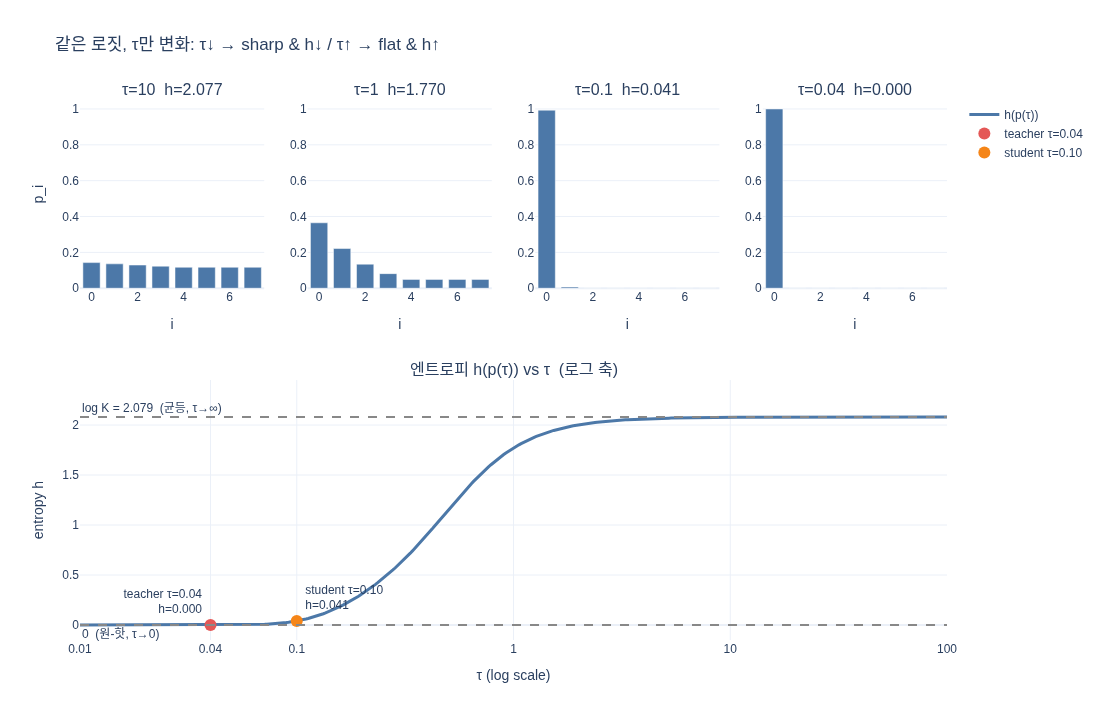

saved expy.png


In [6]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

bar_temps = [10.0, 1.0, 0.1, 0.04]
tau_grid = np.logspace(-2, 2, 400)
h_grid = np.array([entropy(F.softmax(logits / float(t), -1)).item() for t in tau_grid])

fig = make_subplots(
    rows=2,
    cols=4,
    row_heights=[0.42, 0.58],
    vertical_spacing=0.17,
    specs=[
        [{}, {}, {}, {}],
        [{"colspan": 4}, None, None, None],
    ],
    subplot_titles=[f"τ={t:g}  h={entropy(F.softmax(logits / t, -1)):.3f}" for t in bar_temps]
    + ["엔트로피 h(p(τ)) vs τ  (로그 축)"],
)

for c, t in enumerate(bar_temps, start=1):
    p = F.softmax(logits / t, -1).numpy()
    fig.add_trace(
        go.Bar(x=list(range(K)), y=p, marker_color="#4C78A8", showlegend=False),
        row=1,
        col=c,
    )
    fig.update_yaxes(range=[0, 1.05], row=1, col=c)
    fig.update_xaxes(title_text="i", row=1, col=c)
fig.update_yaxes(title_text="p_i", row=1, col=1)

fig.add_trace(
    go.Scatter(x=tau_grid, y=h_grid, mode="lines", line=dict(color="#4C78A8", width=3), name="h(p(τ))"),
    row=2,
    col=1,
)
fig.add_hline(
    y=math.log(K), line=dict(color="#888", dash="dash"),
    annotation_text="log K = 2.079  (균등, τ→∞)", annotation_position="top left",
    row=2, col=1,
)
fig.add_hline(
    y=0.0, line=dict(color="#888", dash="dash"),
    annotation_text="0  (원-핫, τ→0)", annotation_position="bottom left",
    row=2, col=1,
)
anno = [
    (0.04, "teacher τ=0.04", "#E45756", "top left"),
    (0.10, "student τ=0.10", "#F58518", "top right"),
]
for t, label, color, pos in anno:
    h_t = entropy(F.softmax(logits / t, -1)).item()
    fig.add_trace(
        go.Scatter(
            x=[t], y=[h_t], mode="markers+text", marker=dict(size=12, color=color),
            text=[f"{label}<br>h={h_t:.3f}"], textposition=pos, name=label,
        ),
        row=2,
        col=1,
    )

fig.update_xaxes(
    type="log", title_text="τ (log scale)",
    tickvals=[0.01, 0.04, 0.1, 1, 10, 100],
    ticktext=["0.01", "0.04", "0.1", "1", "10", "100"],
    row=2, col=1,
)
fig.update_yaxes(range=[-0.15, 2.45], title_text="entropy h", row=2, col=1)
fig.update_layout(
    height=720,
    width=1100,
    title_text="같은 로짓, τ만 변화: τ↓ → sharp & h↓ / τ↑ → flat & h↑",
    template="plotly_white",
    bargap=0.25,
)

_show(fig)

import os

fig.write_image(os.path.join(os.path.dirname(os.path.abspath(__file__)), "expy.png"), scale=2)
print("saved expy.png")

## 5. 정리

| | $\tau \downarrow$ (작아짐) | $\tau \uparrow$ (커짐) |
|---|---|---|
| 로짓 차이 $ (z_i-z_j)/\tau $ | 확대 | 축소 |
| 분포 모양 | **뾰족(sharp)** | **평평(flat)** |
| 최대 확률 $\max_i p_i$ | $\to 1$ | $\to 1/K$ |
| 엔트로피 $h$ | **낮아짐** $\to 0$ | **높아짐** $\to \log K$ |
| 극한 분포 | argmax one-hot | uniform |

DINO 관점: teacher에 $\tau=0.04$(student의 0.1보다 낮음)를 걸어 target 분포를 뾰족하게 만드는 것이
**sharpening**이고, 이는 $H(q,p) = h(q) + D_{KL}(q\|p)$에서 $h(q)$를 낮춰 균등 붕괴를 막는 역할을 한다.
다만 sharpening만 세게 걸면 반대로 원-핫 붕괴로 가므로 centering과 짝을 이룬다.